# Notebook d'exemple pour ouvrir un .fits du scan du polariseur

Edited by Louise 

In [1]:
import numpy as np
from astropy.io import fits

# Pour les graphiques
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

%matplotlib inline

# Get the data

In [2]:
# Define the path to the FITS file and the scan name
data_path = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/'
#data_path = "C:\\Users\\Administrator\\Documents\\Scripts_Commande_VNA\\CosmoCal_data\\"
scan = '20260312_160306'

# Open the FITS file and view its structure
hdul = fits.open(data_path + f"Scan_{scan}.fits")
hdul.info()  # View structure

Filename: /home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/Scan_20260312_160306.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   (242,)   float64   
  1  MAGNITUDE     1 ImageHDU        10   (242, 4, 39)   float64   
  2  PHASE         1 ImageHDU        10   (242, 4, 39)   float64   


In [3]:
# Access the header of the primary HDU (Header Data Unit)
header = hdul[0].header
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =                  242                                                  
EXTEND  =                    T                                                  
DATATYPE= 'Frequency samples in GHz'                                            
THETA_R =                   90                                                  
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                  242                                                  
STATE_AV=                    T                                                  
COUNT_AV=                    2                                                  
IFBW    =                 10

In [4]:
# Extract relevant parameters from the header
alpha_min = header['ALPH_MI']
alpha_max = header['ALPH_MA']
step = header['STEP']
nfreq = header['POINTS']
traces = ['S21', 'S12', 'S11', 'S22']

# Polariser angle array along the scan
alpha = np.arange(alpha_min, alpha_max + step, step)
print(alpha.shape)

(39,)


In [5]:
freq_samples = hdul[0].data *1e-9  # Access frequency samples [GHz]
mag = hdul[1].data  # Access magnitude [dB]
phi = hdul[2].data  # Access phase [deg]

print(mag.shape)  # Check shape of magnitude data [(nstep, nS, points)]
nstep, nS, nfreqs = mag.shape
print(f"Number of steps: {nstep}, number of S-parameters: {nS}, number of frequency points: {nfreqs}")

# Check frequency samples and find the index of the first sample above 127 GHz
fstart_ind = np.argwhere(freq_samples > 127)[0][0]
print(f"First frequency sample above 127 GHz is at index {fstart_ind}, corresponding to {freq_samples[fstart_ind]:.2f} GHz")

### Convert magnitude from dB to linear scale
mag_lin = 10**(mag/10)

(39, 4, 242)
Number of steps: 39, number of S-parameters: 4, number of frequency points: 242
First frequency sample above 127 GHz is at index 69, corresponding to 127.18 GHz


# Plot the data

## En fonction de l'angle du polariseur

/tmp/ipykernel_22100/2652664593.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')
/tmp/ipykernel_22100/2652664593.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


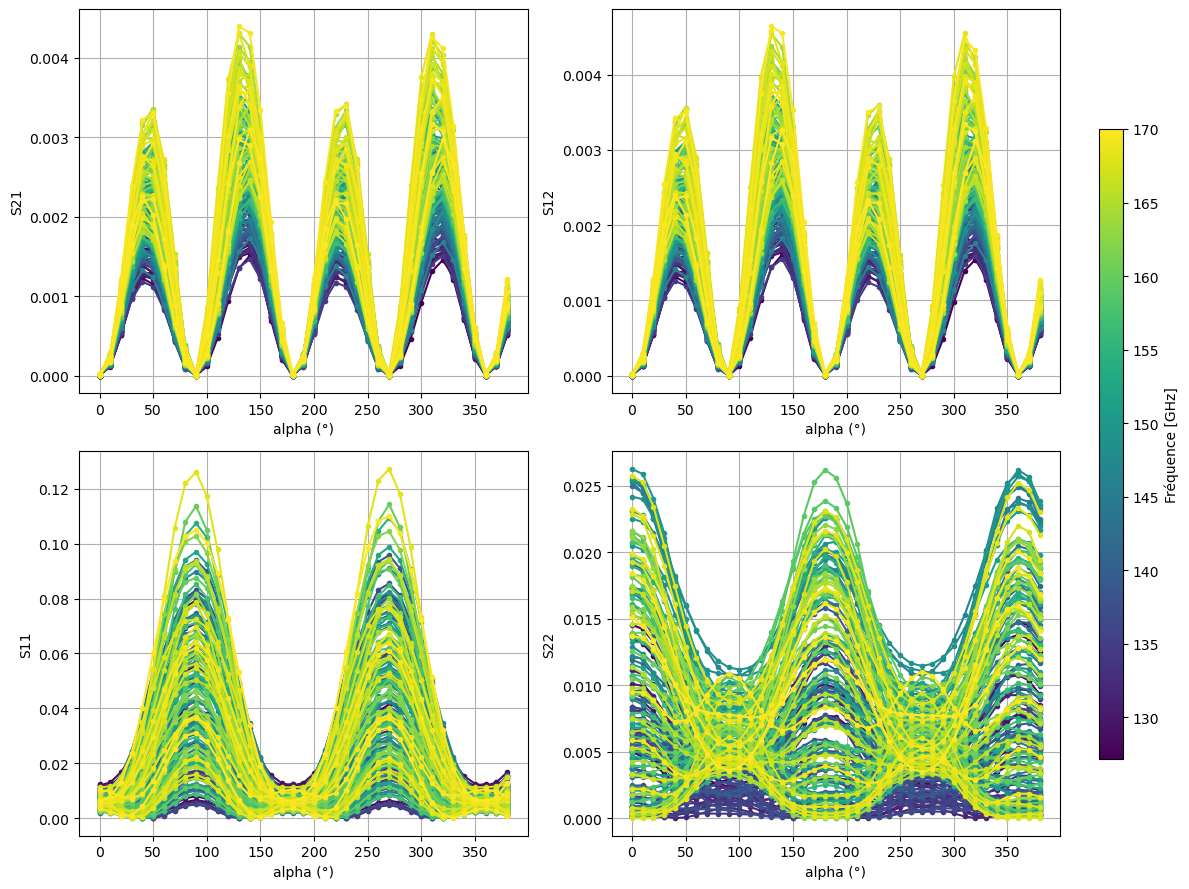

In [7]:
### Plot plusieurs fréquences
#freqs = [0,2, 3, 10, 15, 20, 30, 40] #indices de fréquences à tracer
freqs = np.arange(fstart_ind, nfreqs) # Tracer à partir de la première fréquence au-dessus de 127 GHz

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax = ax.ravel()

# Set-up the color mapping based on the actual frequency values
freq_values = freq_samples[freqs]
norm = Normalize(vmin=freq_values.min(), vmax=freq_values.max())
cmap = plt.cm.get_cmap('viridis')

for t in range(nS):
    for i, f in enumerate(freqs):
        color = cmap(norm(freq_samples[f]))
        ax[t].plot(alpha, mag_lin[:, t, f], '.-', color=color)
       
    ax[t].set_xlabel("alpha (°)")
    ax[t].set_ylabel(f"{traces[t]}")
    ax[t].grid(10)

# Créer une seule colorbar pour tous les plots
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Fréquence [GHz]')

fig.tight_layout(rect=[0, 0, 0.9, 1])

## En fonction de la fréquence

/tmp/ipykernel_22100/1038192754.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma')
/tmp/ipykernel_22100/1038192754.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


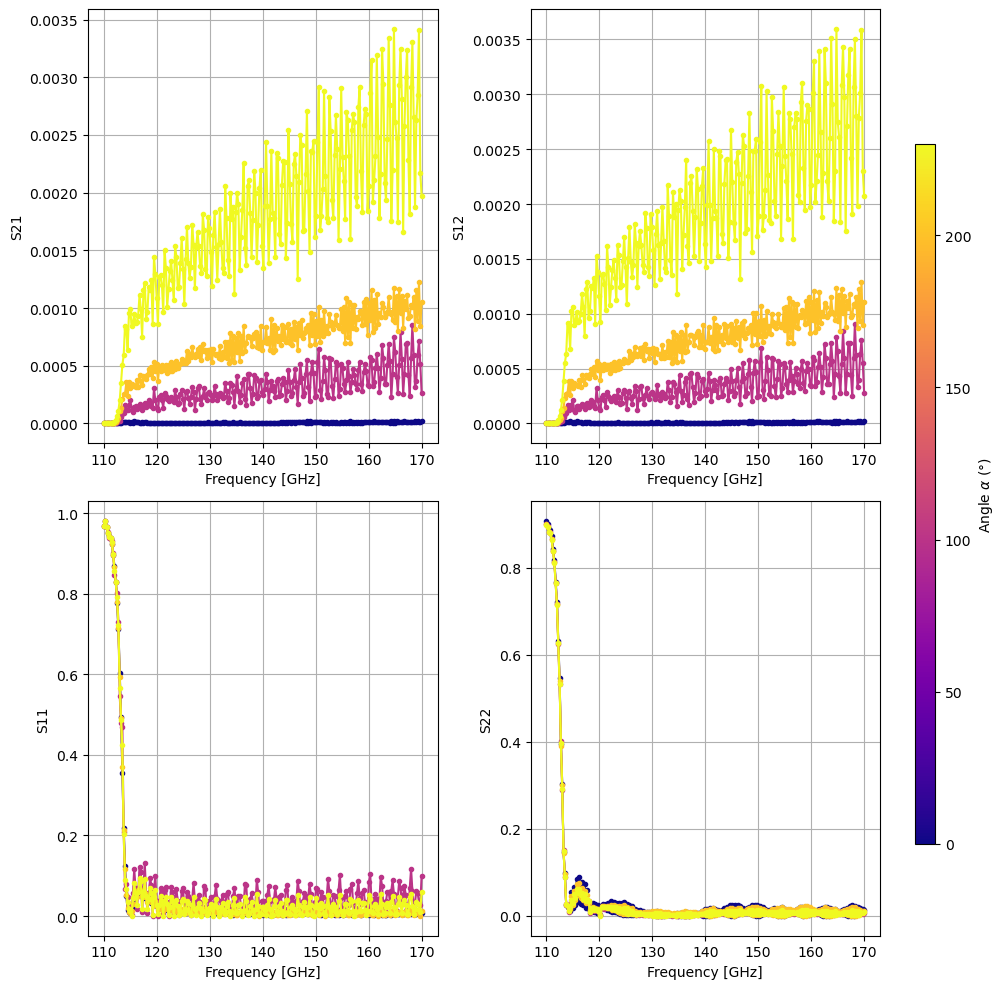

In [10]:
# Indices des angles à tracer (entre 0 et 38)
#alp = np.arange(0, 39) 
alp = [0, 10, 20, 23]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.ravel()

# Set-up the color mapping based on the actual frequency values
alpha_values = alpha[alp]
norm = Normalize(vmin=alpha_values.min(), vmax=alpha_values.max())
cmap = plt.cm.get_cmap('plasma')

for t in range(nS):
    for a in alp:
        color = cmap(norm(alpha[a]))
        ax[t].plot(freq_samples, mag_lin[a, t, :], '.-', color=color) # S21

    ax[t].set_xlabel("Frequency [GHz]")
    ax[t].set_ylabel(f"{traces[t]}")
    ax[t].grid(10)

#créer une colorbar qui montre l'échelle d'indices (ou de valeurs réelles)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'Angle $\alpha$ (°)')

fig.tight_layout(rect=[0, 0, 0.9, 1])